# Forecast Power Demand and Size a Genset

---

## Objectifs du projet:

L'objectif principal de ce projet est de construire un pipeline complet pour prédire la demande d'électricité d'un foyer, puis d'utiliser ces prévisions pour dimensionner un groupe électrogène (genset) de manière optimale.

- Prédire la demande : Vous allez utiliser la variable active power draw (la consommation active en kilowatts) présente dans le fichier household_power_consumption.txt afin d'entraîner et de comparer plusieurs modèles de prévision (tels que SARIMA, Prophet, et XGBoost).


- Dimensionner le générateur : Vous convertirez le pic de consommation prédit par votre meilleur modèle en une recommandation de taille en kVA (kilovoltampères) en appliquant des normes d'ingénierie standard (ISO 8528-1).

- **Le but final est d'éviter de surdimensionner le générateur (ce qui gaspillerait de l'argent) ou de le sous-dimensionner (ce qui provoquerait des pannes lors des pics de consommation).**

---

### C'est quoi un groupe électrogène ?


Un **groupe électrogène** ⚡ est une machine autonome capable de produire de l'électricité là où le réseau électrique n'est pas disponible ou en cas de coupure de courant.

Il fonctionne comme une mini-centrale électrique portative 🏭 et repose sur l'association de deux éléments principaux :
- Un moteur thermique : Il brûle un carburant (essence, diesel ou gaz) pour créer un mouvement mécanique de rotation.
- Un alternateur : Il récupère ce mouvement de rotation et le transforme en énergie électrique.

Pourquoi l'utilise-t-on ?
- Pour le secours : Prendre le relais automatiquement à la maison ou à l'hôpital lors d'une panne de réseau.
- Pour l'autonomie : Alimenter des outils sur un chantier, sur un bateau ou lors d'un événement en extérieur.

---

### C'est quoi la norme ISO 8528-1 ?


La ``norme internationale ISO 8528-1`` est la référence mondiale qui définit les applications, les caractéristiques et les performances des groupes électrogènes ⚡ entraînés par un moteur thermique.

Elle est essentielle car elle établit un langage commun entre constructeurs et utilisateurs pour comparer et dimensionner correctement les équipements. Nous allons explorer cette norme ensemble, et je poserai des questions pour vous guider au fil de votre apprentissage.

Le point le plus important à retenir de l'ISO 8528-1 est la classification des 4 régimes de puissance :

🔴 ESP (Emergency Standby Power) - Puissance de secours : Fourniture d'énergie d'urgence lors d'une coupure du réseau électrique, avec une charge variable et un nombre d'heures annuel limité.

🟢 PRP (Prime Power) - Puissance principale : Fonctionnement continu pour alimenter une charge variable, sans limite d'heures par an (souvent utilisé comme source principale).

🔵 COP (Continuous Power) - Puissance continue : Fourniture continue d'électricité à charge constante (100 %) sans limite d'heures (ex. : centrale électrique de base).

🟡 LTP (Limited-Time Running Power) - Puissance limitée dans le temps : Fourniture d'énergie à charge constante pendant un nombre d'heures limité (ex. : effacement de pointe).

## Read Dataset 
Thr dataset is Measurements of electric power consumption in one household with a one-minute sampling rate over a period of almost 4 years. Different electrical quantities and some sub-metering values are available.

``https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption``

In [1]:
import os
print(os.path.getsize('household_power_consumption.txt') / 1e6, 'MB')


132.960755 MB


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(
    'household_power_consumption.txt',
    sep=';',
    parse_dates={'datetime': ['Date', 'Time']},
    infer_datetime_format=True,
    na_values=['?'],
    low_memory=False
)
df.set_index('datetime', inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')

print('Raw shape:', df.shape)  # (2075259, 7)

C:\Users\tariq\AppData\Local\Temp\ipykernel_9496\1375883534.py:6: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
C:\Users\tariq\AppData\Local\Temp\ipykernel_9496\1375883534.py:6: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(


Raw shape: (2075259, 7)


C:\Users\tariq\AppData\Local\Temp\ipykernel_9496\1375883534.py:6: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


In [3]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


Resample to hourly and prepare the target variable

Minute-level data is too granular for the forecasting models you will build. Resampling to hourly resolution reduces noise and makes model fitting computationally feasible.


In [4]:
# Resample to hourly
df_hourly = df.resample('H').mean()
df_hourly.head()

C:\Users\tariq\AppData\Local\Temp\ipykernel_9496\2776089697.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


``ffill()`` fills any remaining NaN gaps by carrying the last valid observation forward. This handles short gaps where the meter temporarily stopped.

``interpolate(method='time')`` fills any gaps at the start of the series (where forward-fill has no prior value) using time-weighted linear interpolation.

In [5]:
# Handle missing values
df_hourly = df_hourly.ffill().interpolate(method='time')
df_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667




- **Global_active_power (Puissance active globale) :** La puissance électrique réelle totale consommée par le foyer, mesurée en kilowatts (kW) archive.ics.uci.edu. C'est la variable principale que vous cherchez à prédire pour dimensionner le groupe électrogène.



- **Global_reactive_power (Puissance réactive globale) :** La puissance réactive totale consommée par le foyer, mesurée en kilowatts (kW) archive.ics.uci.edu. Elle représente l'énergie magnétisante inutile pour produire un travail direct mais nécessaire au fonctionnement des appareils inductifs (moteurs, transformateurs).



- **Voltage (Tension) :** La tension moyenne par minute dans le foyer, exprimée en volts (V) archive.ics.uci.edu.



- **Global_intensity (Intensité globale) :** L'intensité moyenne du courant électrique circulant dans la maison, exprimée en ampères (A) archive.ics.uci.edu.



- **Sub_metering_1 (Sous-mesure 1)** : L'énergie active consommée par la cuisine (lave-vaisselle, four, micro-ondes), exprimée en watt-heures (Wh) d'énergie active archive.ics.uci.edu.



- **Sub_metering_2 (Sous-mesure 2)** : L'énergie active consommée par la buanderie (lave-linge, sèche-linge, réfrigérateur, lumière), exprimée en watt-heures (Wh) archive.ics.uci.edu.



- **Sub_metering_3 (Sous-mesure 3)** : L'énergie active consommée par le chauffe-eau électrique et la climatisation, également exprimée en watt-heures (Wh) archive.ics.uci.edu.

### L'analogie du thé (puissance active, réactive et apparente)

- Pour bien comprendre la différence entre ces trois puissances électriques en courant alternatif, l'analogie la plus célèbre et la plus simple est celle de la **Verre de thé marocain** .

<center>

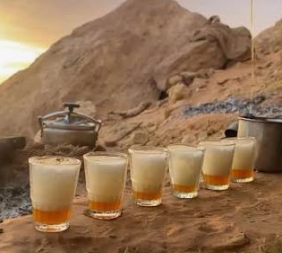

</center>




1. **La Puissance Active ($P$, en Watts - W) 💡**
* **Dans le thé :** C'est le **liquide**, ce que vous buvez vraiment.
* **En électricité :** C'est la puissance réellement transformée en travail utile (mouvement d'un moteur, chaleur d'un radiateur, lumière d'une ampoule).


2. **La Puissance Réactive ($Q$, en VAR - Volt-Ampère Réactif) 🔄**
* **Dans le thé :** C'est la **mousse**. Elle prend de la place dans le verre, mais vous ne la buvez pas.
* **En électricité :** Elle ne produit aucun travail direct, mais elle est indispensable pour créer les champs magnétiques dans les moteurs ou les transformateurs. Elle va et vient entre le réseau et l'appareil.


3. **La Puissance Apparente ($S$, en VA - Volt-Ampère) ⚡**
* **Dans le thé :** C'est le **verre entier** (liquide + mousse). C'est le volume total que le serveur doit vous apporter.
* **En électricité :** C'est la puissance totale que le réseau électrique doit fournir et transporter pour alimenter votre installation.

In [6]:
# Select target
y = df_hourly['Global_active_power']

### Check missing values

In [7]:
print('Hourly shape:', df_hourly.shape)
print('Missing values:', y.isna().sum())

Hourly shape: (34589, 7)
Missing values: 0


### Split into train and test sets

We will use three full years (2007-2009) for training and the final year (2010) for testing. This gives the models enough history to learn seasonal patterns while reserving a clean holdout period.

In [8]:
# Train/test split
train = y['2007':'2009']
test = y['2010']

print('Train shape:', train.shape, '| From:', train.index[0], 'to', train.index[-1])
print('Test shape:', test.shape, '| From:', test.index[0], 'to', test.index[-1])

Train shape: (26304,) | From: 2007-01-01 00:00:00 to 2009-12-31 23:00:00
Test shape: (7918,) | From: 2010-01-01 00:00:00 to 2010-11-26 21:00:00


## Visualize patterns in the training data

Visual inspection is the first diagnostic. You need to see the overall trend, typical daily usage shape, and weekly rhythm before running any statistical tests.



In a new notebook cell, import the diagnostic functions you will use throughout this step by running this code:

In [9]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.diagnostic import acorr_ljungbox

- **adfuller and kpss** are formal stationarity tests with opposing null hypotheses.

- **plot_acf and plot_pacf** visualize autocorrelation at different lags.

- **STL** performs seasonal-trend decomposition using LOESS.

- **acorr_ljungbox** tests whether a sequence of autocorrelations is significantly different from zero.

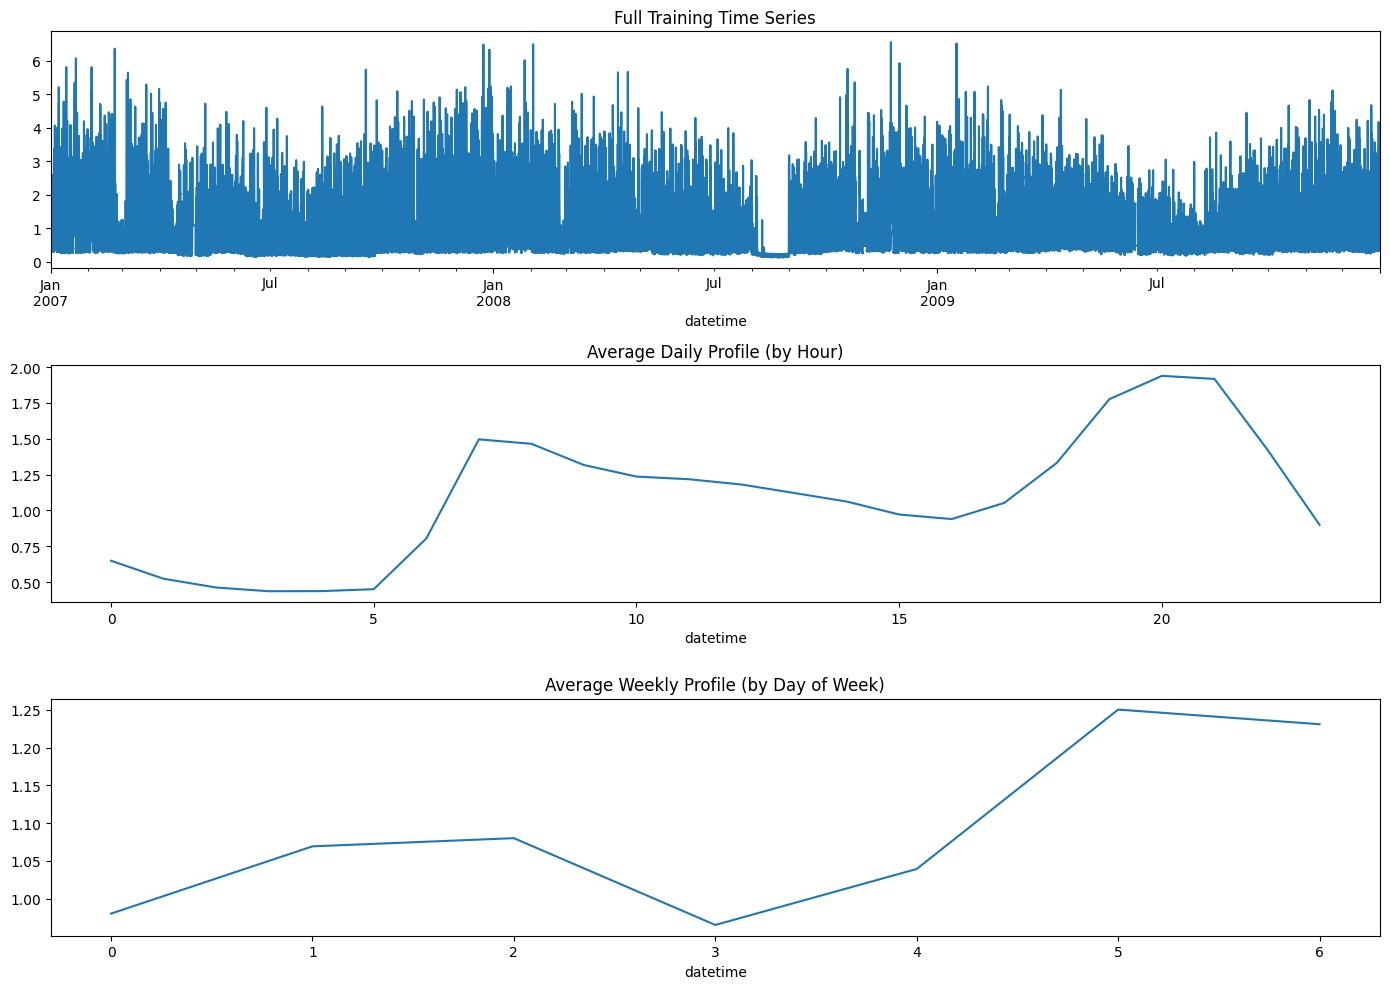

In [10]:
# --- Exploratory Plots ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
train.plot(ax=axes[0], title='Full Training Time Series')
train.groupby(train.index.hour).mean().plot(ax=axes[1], title='Average Daily Profile (by Hour)')
train.groupby(train.index.dayofweek).mean().plot(ax=axes[2], title='Average Weekly Profile (by Day of Week)')
plt.tight_layout()
plt.show()

### Test for stationarity and identify seasonal lags

- A time series must be stationary (constant mean and variance over time) for many forecasting models to work correctly. Two complementary tests give you confidence in the diagnosis.

- The ADF test has a null hypothesis of "the series has a unit root" (non-stationary). The KPSS test has a null hypothesis of "the series is stationary." Running both gives a confirmatory cross-check. If ADF rejects its null AND KPSS fails to reject its null, you have strong evidence of stationarity.

In [11]:
# --- Stationarity Tests ---
adf_result = adfuller(train.dropna())
print(f'ADF p-value: {adf_result[1]:.6f}')  # expect < 0.05 

kpss_result = kpss(train.dropna(), regression='c', nlags='auto')
print(f'KPSS p-value: {kpss_result[1]:.6f}')  # expect > 0.05

ADF p-value: 0.000000
KPSS p-value: 0.010000


C:\Users\tariq\AppData\Local\Temp\ipykernel_9496\2059620850.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(train.dropna(), regression='c', nlags='auto')


- Lorsque ADF dit "stationnaire" (pas de racine unitaire / pas de marche aléatoire) et KPSS dit "non-stationnaire" (pas stationnaire autour d'une constante simple), cela indique généralement que votre série est **stationnaire en tendance (trend-stationary)**.

- Autrement dit : la série a une tendance déterministe claire (par exemple, elle monte ou descend de façon régulière dans le temps), mais elle n'a pas de racine unitaire (elle ne s'éloigne pas de manière imprévisible comme une marche aléatoire).

Généralement, les actions qu'on peut faire c'est: 

- Détrendre la série (retirer la tendance déterministe, par exemple avec une régression linéaire par rapport au temps $t$)
- Différencier la série (calculer $X_t - X_{t-1}$)
- Spécifier l'option regression='ct' (ou trend='c'/'ct') dans les tests statistiques pour vérifier si la stationnarité apparaît une fois la tendance prise en compte.

Rappel: 

- Une marche aléatoire: C’est une série temporelle où la valeur d'aujourd'hui dépend directement de la valeur d'hier, à laquelle s'ajoute un choc imprévisible :$$X_t = X_{t-1} + \epsilon_t$$
    - Caractéristique : Elle possède une racine unitaire. Elle se déplace sans revenir vers une moyenne fixe : sa variance augmente avec le temps.
    - Statut : Elle est non-stationnaire.

- Le Test ADF (Augmented Dickey-Fuller) 
    - Objectif : Chercher si la série contient une racine unitaire (comportement de marche aléatoire).
    - Hypothèse nulle ($H_0$) : Présence d'une racine unitaire ($\Rightarrow$ Non-stationnaire).
    - Décision ($p < 0{,}05$) : On rejette $H_0 \implies$ La série est stationnaire (pas de racine unitaire).3. 
- Le Test KPSS 
    - Objectif : Tester directement la stationnarité autour d'un niveau fixe ou d'une tendance.
    - Hypothèse nulle ($H_0$) : La série est stationnaire.
    - Décision ($p < 0{,}05$) : On rejette $H_0 \implies$ La série est non-stationnaire.

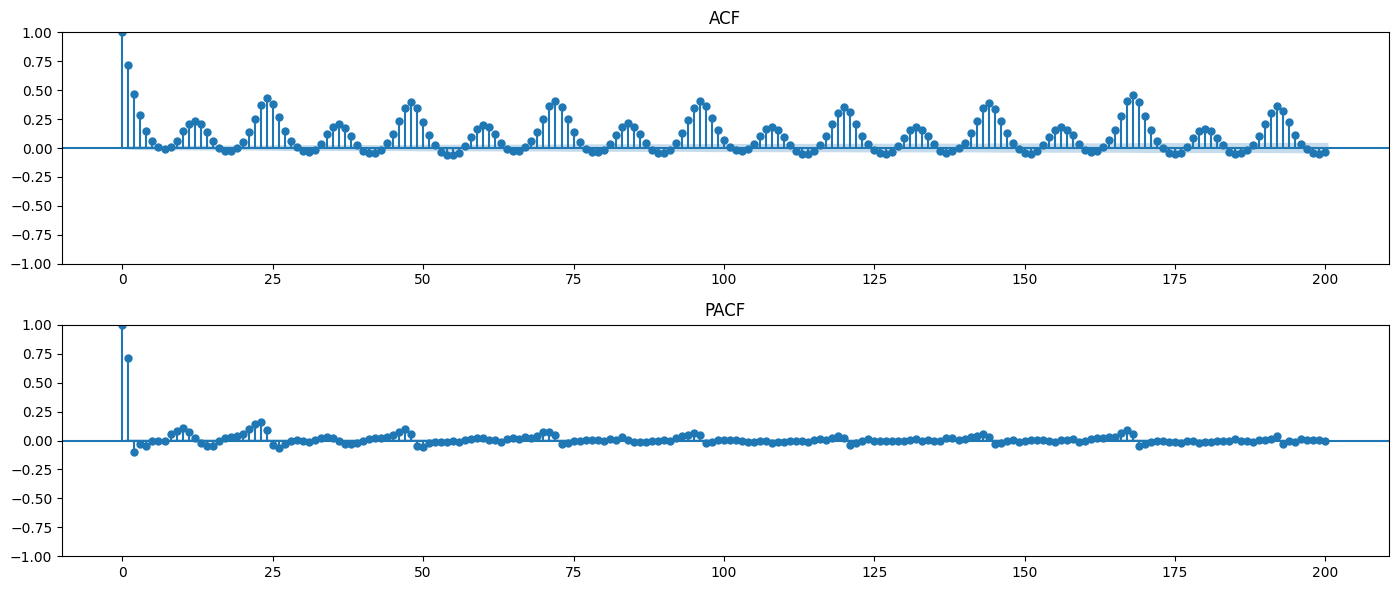

In [12]:
# --- ACF / PACF ---
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
plot_acf(train.dropna(), lags=200, ax=axes[0], title='ACF')
plot_pacf(train.dropna(), lags=200, ax=axes[1], title='PACF')
plt.tight_layout()
plt.show()

- The ACF (Autocorrelation Function) shows how correlated the series is with itself at different lag distances. 
CF (Autocorrelation Function) :Elle mesure la corrélation globale entre la valeur actuelle $Y_t$ et ses valeurs passées $Y_{t-k}$ (les lags ou décalages $k$).Attention : Elle inclut tous les effets indirects (par exemple, la corrélation entre $Y_t$ et $Y_{t-2}$ passe aussi par $Y_{t-1}$).


- The PACF (Partial Autocorrelation Function) isolates the direct correlation at each lag, removing the effect of intermediate lags.
Elle mesure la corrélation directe entre $Y_t$ et $Y_{t-k}$, en retirant l'effet de tous les décalages intermédiaires ($Y_{t-1}, \dots, Y_{t-k+1}$).

- Significant spikes at lag 24 (one day) and lag 168 (one week). These confirm the daily and weekly seasonal periods you spotted in the exploratory plots. 

- La dynamique à court terme est fortement dominée par un processus autorégressif de type AR(2). La valeur actuelle dépend fortement des deux heures précédentes.
- L'ACF ne décroît que très lentement au fil des cycles saisonniers (les vagues restent hautes même après 200 lags). La série n'est pas encore parfaitement stationnaire sur le plan saisonnier.

### Decompose the series and test for heteroscedasticity

Seasonal decomposition separates the series into trend, seasonal, and residual components. Once you isolate the residuals, you can test whether variance is constant or changes over time.

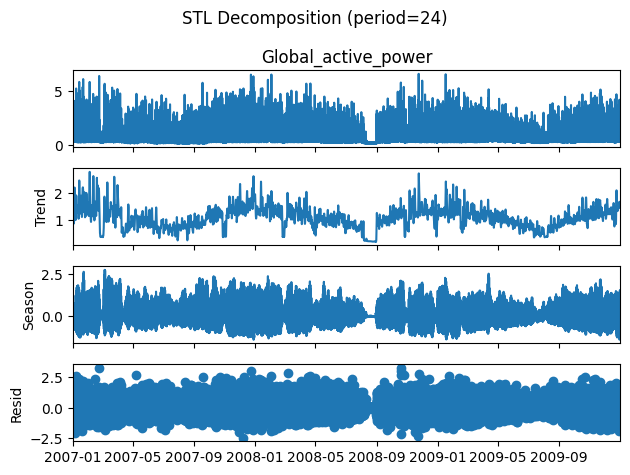

In [13]:
# --- STL Decomposition ---
stl = STL(train.dropna(), period=24)
stl_result = stl.fit()
stl_result.plot()
plt.suptitle('STL Decomposition (period=24)')
plt.tight_layout()
plt.show()

### **Rappel Homoscédasticité/Hétéroscédasticité**

- **Homoscédasticité (idéal):** La dispersion des erreurs est constante tout au long des données. Le modèle fait des erreurs de même grandeur, que la valeur soit petite ou grande.
    - La variance des erreurs est constante pour toutes les observations $i$ : $\operatorname{Var}(\epsilon_i \mid X_i) = \sigma^2$
    est un nombre fixe (ex: toujours égal à $4$). La précision du modèle est la même partout.

- **Hétéroscédasticité (problème) :** La dispersion des erreurs varie (souvent en forme d'entonnoir). Par exemple, les erreurs sont petites pour des petites valeurs, mais deviennent très grandes pour des grandes valeurs.
    - La variance des erreurs n'est pas constante et dépend de l'observation $i$ (souvent de la valeur de $X_i$) :$$\operatorname{Var}(\epsilon_i \mid X_i) = \sigma_i^2$$Le petit indice $i$ sur $\sigma_i^2$ montre que l'incertitude change selon la valeur observée (par exemple, $\sigma_i^2$ augmente quand $X_i$ augmente).
    - Lorsque la variance $\sigma_i^2$ augmente pour de grandes valeurs de $X$, la précision de la prédiction diminue.
        - 📐 Incertitude accrue : Plus l'erreur possible est grande, plus la plage de valeurs plausibles s'élargit.
        - 📊 Impact visuel : L'intervalle de confiance "s'évase" à mesure que $X$ grandit, ce qui donne souvent cette forme caractéristique en entonnoir (ou en éventail) sur le graphique des résidus.

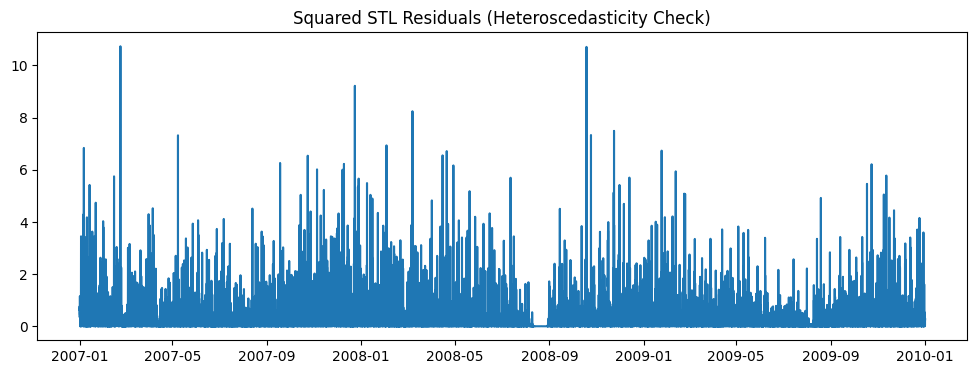

Ljung-Box on squared residuals:
          lb_stat  lb_pvalue
24    6555.098680        0.0
48    7709.094251        0.0
168  12367.270604        0.0


In [14]:
# --- Heteroscedasticity Check ---
residuals = stl_result.resid
plt.figure(figsize=(12, 4))
plt.plot(residuals**2)
plt.title('Squared STL Residuals (Heteroscedasticity Check)')
plt.show()

lb_test = acorr_ljungbox(residuals**2, lags=[24, 48, 168], return_df=True)
print('Ljung-Box on squared residuals:')
print(lb_test)

- **Pourquoi la puissance de deux ?** 
    - **Annuler les signes négatifs:** Un grand écart négatif (ex: $-10$) est une erreur aussi importante qu'un grand écart positif ($+10$). En élevant au carré, $(-10)^2 = 100$ et $10^2 = 100$. Cela permet de mesurer uniquement la taille de la variance.
    - **Détecter la volatilité (la variance) dans le temps :** Si les erreurs ont une variance constante, le graphique de ``residuals**2`` fluctuera autour d'une moyenne stable. Si la variance varie (hétéroscédasticité), vous verrez des périodes avec de très grands pics au carré alterner avec des périodes très meutes (des "clusters" de volatilité).

**Le rôle du test de Ljung-Box sur les résidus au carré**
-  **Le test de Ljung-Box** appliqué directement sur residuals vérifie s'il reste de la corrélation linéaire dans les erreurs.Mais appliqué sur residuals**2, il teste la corrélation de la variance :
    - Si $p\text{-value} < 0{,}05$ : Les résidus au carré sont autocorrelés. Cela signifie que la forte volatilité d'aujourd'hui annonce une forte volatilité demain (effet ARCH / hétéroscédasticité).
    - Si $p\text{-value} > 0{,}05$ : La variance des erreurs est indépendante dans le temps (homoscédasticité).

- le graphique montre clairement des regroupements de volatilité (volatility clustering) :Des périodes très calmes où les résidus au carré sont proches de $0$.Des pics soudains et violents (pouvant dépasser $10$), suivis de périodes d'agitation.

- Il y a bien une hétéroscédasticité dynamique (effet ARCH) marquée dans la série. La variance des erreurs change au fil du temps et dépend des erreurs passées.
    - Un modèle de la famille ARCH / GARCH  (conçu spécifiquement pour modéliser la variance conditionnelle)
    - Pourquoi ARCH / GARCH ?  SARIMA / ARIMA : Modélise la moyenne de la série (les tendances, la saisonnalité).GARCH : Modélise la variance (l'incertitude ou le risque) autour de cette moyenne.
    - La transformation Logarithme ($\ln(Y_t)$) 📉 :Elle écrase fortement les très grandes valeurs tout en impactant peu les petites valeurs.Résultat : Les pics géants deviennent beaucoup plus modérés, et la largeur des vagues devient régulière sur tout le graphique.
    


## Modeling and prepering the training data

### **1-parametrecic models**

In [15]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# 7-day test window (168 hours)
test_7d = test.iloc[:168]

- ExponentialSmoothing is the ETS (Error-Trend-Seasonal) model class from statsmodels.

- SARIMAX is the seasonal ARIMA class that handles both pure SARIMA and models with exogenous regressors.

- test_7d = test.iloc[:168] slices exactly 168 hours (7 days) from the test set. Every model predicts the same 168 values, making comparison fair.

### Fit an ETS model with additive seasonality

- Exponential Smoothing (ETS) is one of the simplest parametric forecasting methods. It decomposes a time series into error, trend, and seasonal components and forecasts by exponentially weighting recent observations.

- trend='add' and seasonal='add' specify additive trend and seasonal components. Additive means the seasonal pattern has a constant amplitude regardless of the trend level.

- seasonal_periods=24 tells the model to look for a repeating pattern every 24 hours (one daily cycle).

- ets_model.forecast(168) generates predictions for the next 168 hourly timestamps, covering exactly 7 days.

- RMSE penalizes large errors heavily. MAE gives the average absolute deviation. Together they quantify how far off the forecast is.

In [16]:
# --- ETS Model ---
ets_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=24
).fit(optimized=True)

ets_forecast = ets_model.forecast(168)
ets_rmse = np.sqrt(mean_squared_error(test_7d, ets_forecast))
ets_mae = mean_absolute_error(test_7d, ets_forecast)
ets_metrics = {'RMSE': ets_rmse, 'MAE': ets_mae}
print(f'ETS RMSE: {ets_rmse:.4f} | MAE: {ets_mae:.4f}')

ETS RMSE: 1.2671 | MAE: 1.0906


- RMSE (1.2671) : Cette métrique pénalise de façon plus sévère les erreurs importantes. Pour le dimensionnement de notre groupe électrogène, elle est essentielle car un modèle qui rate de beaucoup un pic de consommation est très dangereux.

- MAE (1.0906) : Elle vous donne l'erreur absolue moyenne de vos prévisions (en kilowatts). En moyenne, vos prédictions dévient de seulement ~1,09 kW de la réalité.

### Fit SARIMA and diagnose its residuals

- SARIMA (Seasonal AutoRegressive Integrated Moving Average) is a more flexible parametric model. It captures both short-term autocorrelation and seasonal patterns through explicit AR and MA terms at both regular and seasonal lags.

In [40]:
order_n = (1, 1, 1)


# --- SARIMA Model ---
sarima_model = SARIMAX(
    train,
    order=order_n,
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(sarima_model.summary())

sarima_forecast = sarima_model.forecast(168)
sarima_rmse = np.sqrt(mean_squared_error(test_7d, sarima_forecast))
sarima_mae = mean_absolute_error(test_7d, sarima_forecast)
sarima_metrics = {'RMSE': sarima_rmse, 'MAE': sarima_mae}
print(f'SARIMA RMSE: {sarima_rmse:.4f} | MAE: {sarima_mae:.4f}')

                                     SARIMAX Results                                      
Dep. Variable:                Global_active_power   No. Observations:                26304
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 24)   Log Likelihood              -22837.607
Date:                            Sun, 26 Jul 2026   AIC                          45685.214
Time:                                    10:49:04   BIC                          45726.096
Sample:                                01-01-2007   HQIC                         45698.415
                                     - 12-31-2009                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6118      0.004    166.319      0.000       0.605       0.619
ma.L1         -0.9921      0.001  -

# Analyse détaillée des résultats du modèle SARIMAX

Cette section présente une interprétation détaillée des résultats obtenus avec le modèle **SARIMAX**, accompagnée d'un rappel des principales métriques statistiques.

---

## 1. Informations générales

### Variable dépendante

```text
Dep. Variable: Global_active_power
```

**Rappel**

La variable dépendante est la variable que le modèle cherche à prédire.

**Interprétation**

Le modèle prédit la **puissance active globale** (*Global_active_power*).

---

### Nombre d'observations

```text
No. Observations: 26304
```

**Rappel**

Il s'agit du nombre d'observations utilisées pour estimer les paramètres du modèle.

**Interprétation**

Le modèle a été entraîné sur **26 304 observations**. Plus le nombre d'observations est élevé, plus les estimations des paramètres sont généralement fiables.

---

### Structure du modèle

```text
Model: SARIMAX(1,1,1)x(1,0,1,24)
```

Un modèle SARIMA est défini par :

$$
(p,d,q)\times(P,D,Q,s)
$$

avec :

### Partie non saisonnière

- **p = 1** : composante autorégressive (AR)
- **d = 1** : une différenciation
- **q = 1** : composante moyenne mobile (MA)

### Partie saisonnière

- **P = 1** : composante autorégressive saisonnière
- **D = 0** : aucune différenciation saisonnière
- **Q = 1** : composante moyenne mobile saisonnière
- **s = 24** : période saisonnière de 24 observations

**Interprétation**

Le modèle tient compte d'une saisonnalité de **24 pas de temps**, ce qui correspond par exemple à un cycle journalier pour des données horaires.

---

# 2. Qualité globale du modèle

## Log Likelihood

```text
Log Likelihood = -22837.607
```

### Rappel

La log-vraisemblance mesure la capacité du modèle à expliquer les données observées.

- Plus elle est élevée (donc moins négative), meilleur est le modèle.
- Elle est principalement utilisée pour comparer plusieurs modèles.

**Interprétation**

Cette valeur n'a pas d'interprétation absolue. Elle est utile uniquement lors de la comparaison de plusieurs modèles SARIMA.

---

## AIC

```text
AIC = 45685.214
```

### Rappel

L'**Akaike Information Criterion (AIC)** évalue le compromis entre :

- la qualité d'ajustement ;
- la complexité du modèle.

Sa formule est :

$$
AIC=-2\log(L)+2k
$$

où :

- \(L\) est la vraisemblance ;
- \(k\) est le nombre de paramètres.

**Interprétation**

Plus l'AIC est faible, meilleur est le modèle.

Il est uniquement utilisé pour comparer plusieurs modèles.

---

## BIC

```text
BIC = 45726.096
```

### Rappel

Le **Bayesian Information Criterion (BIC)** est similaire à l'AIC mais pénalise davantage les modèles complexes.

$$
BIC=-2\log(L)+k\log(n)
$$

où \(n\) représente le nombre d'observations.

**Interprétation**

Comme pour l'AIC, **plus le BIC est faible, meilleur est le modèle**.

---

## HQIC

```text
HQIC = 45698.415
```

### Rappel

Le **Hannan-Quinn Information Criterion (HQIC)** est un autre critère de comparaison situé entre l'AIC et le BIC.

**Interprétation**

Comme pour les deux critères précédents, une valeur plus faible indique un meilleur compromis entre qualité d'ajustement et complexité.

---

# 3. Analyse des coefficients

## Coefficient AR(1)

```text
ar.L1 = 0.6118
```

### Rappel

Le terme **AR (AutoRegressive)** représente l'influence des observations passées sur la valeur actuelle.

**Interprétation**

Le coefficient vaut **0,6118**.

Comme :

$$
0<0.6118<1
$$

la série présente une **persistance positive** : les valeurs passées influencent fortement les valeurs présentes sans rendre le processus instable.

---

## Coefficient MA(1)

```text
ma.L1 = -0.9921
```

### Rappel

Le terme **MA (Moving Average)** modélise l'influence des erreurs passées.

**Interprétation**

Le coefficient est très proche de **−1**, ce qui indique que les erreurs précédentes jouent un rôle important dans la correction des prévisions.

---

## Coefficient AR saisonnier

```text
ar.S.L24 = 0.9959
```

### Rappel

Cette composante mesure l'influence de la valeur observée **24 périodes auparavant**.

**Interprétation**

Le coefficient étant quasiment égal à **1**, la dépendance saisonnière est extrêmement forte.

La consommation observée 24 périodes auparavant explique presque directement la consommation actuelle.

---

## Coefficient MA saisonnier

```text
ma.S.L24 = -0.9530
```

### Rappel

Cette composante modélise les erreurs saisonnières.

**Interprétation**

Le modèle corrige fortement les erreurs réalisées une saison auparavant.

---

# 4. Variance des résidus

## Variance résiduelle

```text
sigma² = 0.3322
```

### Rappel

Cette valeur représente la variance des erreurs résiduelles.

Plus elle est faible, plus les erreurs de prédiction sont faibles.

L'écart-type associé est :

$$
\sigma=\sqrt{0.3322}\approx0.576
$$

**Interprétation**

Les résidus présentent un écart-type d'environ **0,58 unité de puissance**.

---

# 5. Significativité des coefficients

## Erreur standard

```text
std err
```

### Rappel

L'erreur standard mesure la précision de l'estimation d'un coefficient.

**Interprétation**

Toutes les erreurs standards sont très faibles, ce qui traduit une estimation très précise des coefficients.

---

## Statistique z

```text
z
```

### Rappel

La statistique est calculée par :

$$
z=\frac{\text{coefficient}}{\text{erreur standard}}
$$

Une valeur absolue supérieure à **1,96** indique généralement que le coefficient est statistiquement significatif au seuil de 5 %.

**Interprétation**

Les statistiques **z** sont extrêmement élevées, ce qui confirme la significativité des paramètres.

---

## p-value

```text
P>|z|
```

### Rappel

La p-value permet de tester l'hypothèse :

- **H₀ : le coefficient est nul.**

Règle de décision :

- p < 0,05 : coefficient significatif ;
- p > 0,05 : coefficient non significatif.

**Interprétation**

Toutes les p-values sont inférieures à **0,001**.

Les coefficients sont donc **hautement significatifs**.

---

## Intervalle de confiance

```text
[0.025 ; 0.975]
```

### Rappel

Il s'agit de l'intervalle de confiance à 95 %.

**Interprétation**

Aucun intervalle ne contient zéro.

Cela confirme la significativité des coefficients.

---

# 6. Analyse des résidus

## Test de Ljung-Box

```text
Q = 3.12
Prob(Q) = 0.08
```

### Rappel

Ce test vérifie l'absence d'autocorrélation des résidus.

Hypothèses :

- **H₀ :** les résidus ne sont pas autocorrélés ;
- **H₁ :** les résidus sont autocorrélés.

**Interprétation**

La p-value vaut **0,08**, supérieure au seuil de 5 %.

On **ne rejette pas H₀**.

Le modèle semble donc avoir correctement capturé la dépendance temporelle de la série.

---

## Test de Jarque-Bera

```text
JB = 18777.51
Prob(JB) = 0.00
```

### Rappel

Ce test vérifie si les résidus suivent une loi normale.

Hypothèses :

- **H₀ :** les résidus suivent une loi normale ;
- **H₁ :** les résidus ne suivent pas une loi normale.

**Interprétation**

La p-value étant quasiment nulle, on rejette H₀.

Les résidus ne suivent donc pas une distribution normale. Cela peut être dû à la présence de valeurs extrêmes ou à une asymétrie importante.

---

## Skewness

```text
Skew = 1.05
```

### Rappel

La skewness mesure l'asymétrie d'une distribution.

- 0 : distribution symétrique ;
- > 0 : asymétrie à droite ;
- < 0 : asymétrie à gauche.

**Interprétation**

Les résidus présentent une **asymétrie positive**, avec une queue plus importante vers les grandes valeurs.

---

## Kurtosis

```text
Kurtosis = 6.57
```

### Rappel

La kurtosis mesure l'épaisseur des queues de la distribution.

Une loi normale possède une kurtosis égale à **3**.

**Interprétation**

Avec une valeur de **6,57**, les résidus présentent des **queues épaisses**, ce qui signifie que les valeurs extrêmes sont plus fréquentes qu'avec une loi normale.

---

## Test d'hétéroscédasticité

```text
H = 0.74
Prob(H) = 0.00
```

### Rappel

Ce test vérifie si la variance des résidus est constante.

Hypothèses :

- **H₀ :** variance constante ;
- **H₁ :** variance variable.

**Interprétation**

La p-value étant inférieure à 0,05, on rejette H₀.

La variance des erreurs varie donc au cours du temps.

---

# 7. Performances prédictives

## RMSE

```text
RMSE = 0.7825
```

### Rappel

Le **Root Mean Squared Error (RMSE)** mesure la taille moyenne des erreurs en pénalisant davantage les erreurs importantes.

$$
RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})^2}
$$

**Interprétation**

Le modèle commet une erreur moyenne d'environ **0,78 unité**.

---

## MAE

```text
MAE = 0.6474
```

### Rappel

Le **Mean Absolute Error (MAE)** correspond à la moyenne des erreurs absolues.

$$
MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y_i}|
$$

**Interprétation**

Le modèle se trompe en moyenne d'environ **0,65 unité**.

Le fait que **RMSE > MAE** est normal, car le RMSE pénalise davantage les erreurs importantes.

---

# Conclusion générale

Le modèle **SARIMAX(1,1,1)(1,0,1,24)** présente de bonnes performances globales.

### Points forts

- Tous les coefficients sont **hautement significatifs** (*p* < 0,001).
- La composante saisonnière de période **24** est très marquée, ce qui montre que le modèle capture efficacement la saisonnalité quotidienne.
- Le test de **Ljung-Box** indique que les résidus ne présentent plus d'autocorrélation significative, signe que la dépendance temporelle est correctement modélisée.
- Les performances de prédiction (**RMSE = 0,7825** et **MAE = 0,6474**) montrent une précision satisfaisante.

### Limites

- Les résidus ne suivent pas une loi normale (test de Jarque-Bera significatif).
- La variance des résidus n'est pas constante (hétéroscédasticité), indiquant des périodes de volatilité plus importante.

### Bilan

Dans l'ensemble, ce modèle constitue un **bon compromis entre qualité d'ajustement et capacité prédictive**. Il capture efficacement la dépendance temporelle et la saisonnalité de la série. Les principales pistes d'amélioration concernent la modélisation de la distribution des résidus et de leur variance, par exemple à l'aide de modèles plus sophistiqués (SARIMAX avec variables exogènes, modèles GARCH sur les résidus ou modèles non linéaires).

Par contre, les pics sont très pénalisante d'un point de vue métier RMSE.

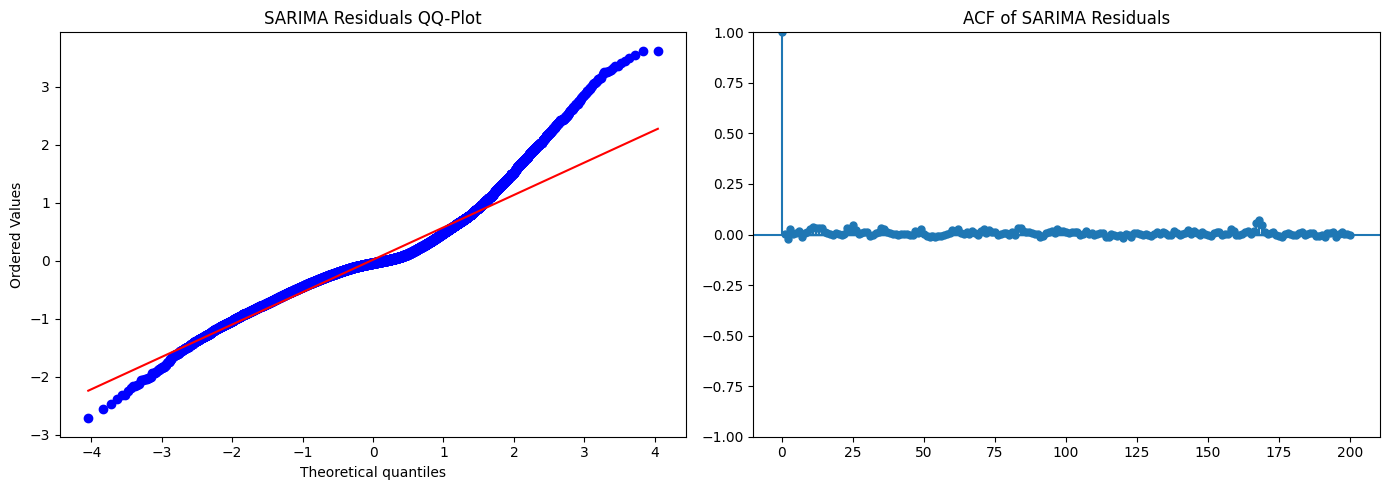

In [18]:
# --- SARIMA Residual Diagnostics ---
sarima_resid = sarima_model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
import scipy.stats as stats
stats.probplot(sarima_resid.dropna(), dist='norm', plot=axes[0])
axes[0].set_title('SARIMA Residuals QQ-Plot')
plot_acf(sarima_resid.dropna(), lags=200, ax=axes[1], title='ACF of SARIMA Residuals')
plt.tight_layout()
plt.show()

- The SARIMA model with seasonal_order=(1, 0, 1, 24) captures daily seasonality but completely misses the weekly cycle at lag 168. Those spikes are predictable structure left on the table.


- Setting the seasonal period to 168 (weekly) in statsmodels is computationally prohibitive. The state-space representation grows with the seasonal period, making s=168 impractical for 26,000+ observations.

- This is the exact gap that Prophet and SARIMAX with exogenous calendar features will fix in the next step. Prophet handles multiple seasonalities natively, and exogenous day-of-week features let SARIMAX encode weekly patterns without expanding the seasonal period

### Rajouter des variables exogénes avec Prophet et SARIMAX

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from prophet import Prophet

In [20]:
# --- Calendar Feature Engineering ---
def make_calendar_features(index):
    """Create cyclical time features from a DatetimeIndex."""
    df_feat = pd.DataFrame(index=index)
    # Cyclical hour encoding (0-23 mapped to unit circle)
    df_feat['hour_sin'] = np.sin(2 * np.pi * index.hour / 24)
    df_feat['hour_cos'] = np.cos(2 * np.pi * index.hour / 24)
    # Cyclical day-of-week encoding (0-6 mapped to unit circle)
    df_feat['dow_sin'] = np.sin(2 * np.pi * index.dayofweek / 7)
    df_feat['dow_cos'] = np.cos(2 * np.pi * index.dayofweek / 7)
    # Binary weekend flag
    df_feat['is_weekend'] = (index.dayofweek >= 5).astype(int)
    return df_feat

train_exog = make_calendar_features(train.index)
test_7d_exog = make_calendar_features(test_7d.index)
print(train_exog.head(8))

                     hour_sin      hour_cos  dow_sin  dow_cos  is_weekend
datetime                                                                 
2007-01-01 00:00:00  0.000000  1.000000e+00      0.0      1.0           0
2007-01-01 01:00:00  0.258819  9.659258e-01      0.0      1.0           0
2007-01-01 02:00:00  0.500000  8.660254e-01      0.0      1.0           0
2007-01-01 03:00:00  0.707107  7.071068e-01      0.0      1.0           0
2007-01-01 04:00:00  0.866025  5.000000e-01      0.0      1.0           0
2007-01-01 05:00:00  0.965926  2.588190e-01      0.0      1.0           0
2007-01-01 06:00:00  1.000000  6.123234e-17      0.0      1.0           0
2007-01-01 07:00:00  0.965926 -2.588190e-01      0.0      1.0           0


- La fonction `make_calendar_features` prend un objet `DatetimeIndex` en entrée et retourne un `DataFrame` contenant cinq variables calendaires. Chacune de ces variables apporte au modèle une information complémentaire sur le moment où chaque observation a été enregistrée.

- Les variables `hour_sin` et `hour_cos` encodent de manière cyclique les **24 heures de la journée**. Cette représentation permet de préserver la continuité temporelle, en considérant par exemple que **23 h et 0 h sont des heures consécutives**, contrairement à un encodage numérique classique.

- Les variables `dow_sin` et `dow_cos` appliquent le même principe au **cycle hebdomadaire de 7 jours**. Elles permettent au modèle de capturer les variations liées aux jours de la semaine, notamment les effets saisonniers hebdomadaires qui peuvent ne pas être entièrement modélisés par le SARIMA.

- La variable `is_weekend` est une variable binaire prenant la valeur **1 pour le samedi et le dimanche**, et **0 pour les autres jours**. Elle permet au modèle de distinguer les comportements de consommation électrique spécifiques au week-end, souvent différents de ceux observés en semaine.

### Fit Prophet with daily and weekly seasonality

Prophet expects a DataFrame with two columns: ds (datetime) and y (values). It decomposes the series into trend, seasonalities, and holidays internally. You enable daily and weekly seasonality so it captures both the 24-hour and 168-hour patterns your SARIMA model could not.

In [21]:
# --- Prophet Model ---
# Reshape training data into Prophet's expected format
train_prophet = train.reset_index().rename(
    columns={'datetime': 'ds', 'Global_active_power': 'y'}
)

# Fit with explicit daily + weekly seasonality
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)
prophet_model.fit(train_prophet)

09:28:30 - cmdstanpy - INFO - Chain [1] start processing
09:28:38 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
# Generate 168-hour (7-day) forecast
# future = prophet_model.make_future_dataframe(periods=168, freq='H')
future = prophet_model.make_future_dataframe(periods=168, freq='H', include_history=False)
prophet_pred = prophet_model.predict(future)
prophet_forecast = prophet_pred.set_index('ds')['yhat'].loc[test_7d.index]

# Compute error metrics
prophet_rmse = np.sqrt(mean_squared_error(test_7d, prophet_forecast))
prophet_mae = mean_absolute_error(test_7d, prophet_forecast)
prophet_mape = np.mean(np.abs(
    (test_7d.values - prophet_forecast.values) / test_7d.values
)) * 100
prophet_metrics = {'RMSE': prophet_rmse, 'MAE': prophet_mae, 'MAPE': prophet_mape}
print(f'Prophet RMSE: {prophet_rmse:.4f} | MAE: {prophet_mae:.4f} | MAPE: {prophet_mape:.2f}%')

Prophet RMSE: 0.7088 | MAE: 0.5700 | MAPE: 86.04%


### Fit SARIMAX with calendar features and compare residuals

SARIMAX is the same SARIMA model but with an exog parameter that accepts your external feature matrix. By feeding in the calendar features you engineered, you give the model explicit information about weekly patterns that s=24 alone cannot capture.

In [23]:
# --- SARIMAX Model ---
sarimax_model = SARIMAX(
    train,
    exog=train_exog,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, low_memory=True)

# Generate forecast with exogenous features for the test period
sarimax_forecast = sarimax_model.forecast(168, exog=test_7d_exog)
sarimax_rmse = np.sqrt(mean_squared_error(test_7d, sarimax_forecast))
sarimax_mae = mean_absolute_error(test_7d, sarimax_forecast)
sarimax_mape = np.mean(np.abs(
    (test_7d.values - sarimax_forecast.values) / test_7d.values
)) * 100
sarimax_metrics = {'RMSE': sarimax_rmse, 'MAE': sarimax_mae, 'MAPE': sarimax_mape}
print(f'SARIMAX RMSE: {sarimax_rmse:.4f} | MAE: {sarimax_mae:.4f} | MAPE: {sarimax_mape:.2f}%')

SARIMAX RMSE: 0.7101 | MAE: 0.5433 | MAPE: 78.44%


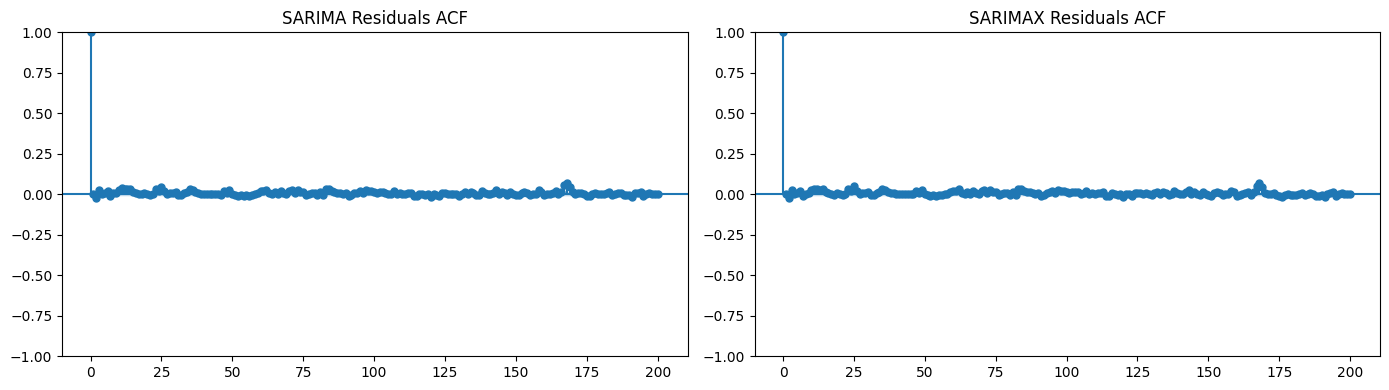

In [24]:
# --- Compare SARIMAX vs SARIMA Residual ACF ---
sarimax_resid = sarimax_model.resid
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(sarima_model.resid.dropna(), lags=200, ax=axes[0], title='SARIMA Residuals ACF')
plot_acf(sarimax_resid.dropna(), lags=200, ax=axes[1], title='SARIMAX Residuals ACF')
plt.tight_layout()
plt.show()

### Forecast with XGBoost


The parametric models from the previous steps revealed their limits. SARIMA could not capture weekly seasonality without prohibitive computation, and Prophet and SARIMAX improved by adding calendar features.

Tree-based ML models can capture non-linear interactions between features that parametric models cannot. XGBoost with engineered features is the proven top performer for tabular time-series forecasting. In this step, you train an XGBoost model and run a final head-to-head comparison of all five models.

In [25]:
from xgboost import XGBRegressor

# --- XGBoost Feature Engineering ---
def make_xgb_features(series):
    df_feat = pd.DataFrame({'y': series})
    df_feat['lag_1'] = df_feat['y'].shift(1)
    df_feat['lag_24'] = df_feat['y'].shift(24)
    df_feat['lag_168'] = df_feat['y'].shift(168)
    df_feat['rolling_mean_24'] = df_feat['y'].shift(1).rolling(24).mean()
    df_feat['rolling_std_24'] = df_feat['y'].shift(1).rolling(24).std()
    df_feat['hour_sin'] = np.sin(2 * np.pi * series.index.hour / 24)
    df_feat['hour_cos'] = np.cos(2 * np.pi * series.index.hour / 24)
    df_feat['dow_sin'] = np.sin(2 * np.pi * series.index.dayofweek / 7)
    df_feat['dow_cos'] = np.cos(2 * np.pi * series.index.dayofweek / 7)
    df_feat['is_weekend'] = (series.index.dayofweek >= 5).astype(int)
    return df_feat.drop(columns=['y'])

full_series = pd.concat([train, test_7d])
full_features = make_xgb_features(full_series)

train_features = full_features.loc[train.index].dropna()
y_train = train.loc[train_features.index]

test_7d_features = full_features.loc[test_7d.index].dropna()
y_test_7d = test_7d.loc[test_7d_features.index]

### Training the model

In [26]:
# Train XGBoost
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
xgb_model.fit(train_features, y_train)

xgb_predictions = xgb_model.predict(test_7d_features)
xgb_rmse = np.sqrt(mean_squared_error(y_test_7d, xgb_predictions))
xgb_mae = mean_absolute_error(y_test_7d, xgb_predictions)
xgb_mape = np.mean(np.abs((y_test_7d.values - xgb_predictions) / y_test_7d.values)) * 100
xgb_metrics = {'RMSE': xgb_rmse, 'MAE': xgb_mae, 'MAPE': xgb_mape}

# Best model forecast
best_forecast = xgb_predictions

### Visualiser la prédiction et le backtest

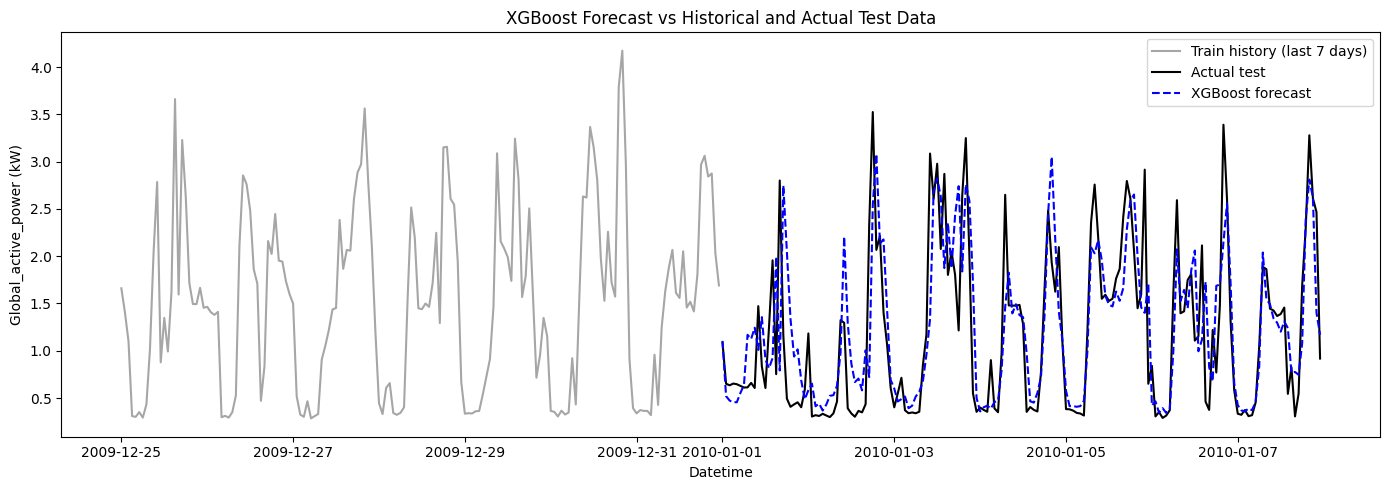

In [44]:
plt.figure(figsize=(14, 5))
plt.plot(train.index[-168:], train[-168:], label='Train history (last 7 days)', color='gray', alpha=0.7)
plt.plot(test_7d.index, test_7d, label='Actual test', color='black', linewidth=1.5)
plt.plot(test_7d.index, xgb_predictions, label='XGBoost forecast', color='blue', linestyle='--', linewidth=1.5)
plt.title('XGBoost Forecast vs Historical and Actual Test Data')
plt.xlabel('Datetime')
plt.ylabel('Global_active_power (kW)')
plt.legend()
plt.tight_layout()
plt.show()

### Visualiser les prédictions avec les intervalles de confiances

In [45]:
import numpy as np
import pandas as pd

# Compute 95% prediction intervals for available models/forecasts
alpha = 0.05  # 95% PI

# Prophet (already has yhat_lower / yhat_upper in prophet_pred)
prophet_ci = prophet_pred.set_index('ds').loc[test_7d.index, ['yhat', 'yhat_lower', 'yhat_upper']]
prophet_ci.columns = ['prophet_point', 'prophet_lower', 'prophet_upper']

# SARIMA (no exog)
sarima_pred = sarima_model.get_prediction(start=test_7d.index[0], end=test_7d.index[-1])
sarima_ci_df = sarima_pred.conf_int(alpha=alpha)
sarima_point = sarima_pred.predicted_mean
sarima_lower = sarima_ci_df.iloc[:, 0]
sarima_upper = sarima_ci_df.iloc[:, 1]
sarima_ci = pd.DataFrame({
    'sarima_point': sarima_point,
    'sarima_lower': sarima_lower,
    'sarima_upper': sarima_upper
}, index=test_7d.index)

# SARIMAX (with exog)
sarimax_pred = sarimax_model.get_prediction(start=test_7d.index[0], end=test_7d.index[-1], exog=test_7d_exog)
sarimax_ci_df = sarimax_pred.conf_int(alpha=alpha)
sarimax_point = sarimax_pred.predicted_mean
sarimax_lower = sarimax_ci_df.iloc[:, 0]
sarimax_upper = sarimax_ci_df.iloc[:, 1]
sarimax_ci = pd.DataFrame({
    'sarimax_point': sarimax_point,
    'sarimax_lower': sarimax_lower,
    'sarimax_upper': sarimax_upper
}, index=test_7d.index)

# XGBoost: empirical residual quantiles on training set -> add to point forecasts
train_preds_xgb = xgb_model.predict(train_features)
residuals_xgb = y_train.values - train_preds_xgb
q_low, q_high = np.quantile(residuals_xgb, [alpha/2, 1 - alpha/2])
xgb_point = pd.Series(xgb_predictions, index=test_7d.index)
xgb_ci = pd.DataFrame({
    'xgb_point': xgb_point,
    'xgb_lower': xgb_point + q_low,
    'xgb_upper': xgb_point + q_high
})

# ETS: try model-based CI if available, otherwise empirical residuals
try:
    ets_pred = ets_model.get_prediction(start=test_7d.index[0], end=test_7d.index[-1])
    ets_ci_df = ets_pred.conf_int(alpha=alpha)
    ets_point = ets_pred.predicted_mean
    ets_lower = ets_ci_df.iloc[:, 0]
    ets_upper = ets_ci_df.iloc[:, 1]
    ets_ci = pd.DataFrame({
        'ets_point': ets_point,
        'ets_lower': ets_lower,
        'ets_upper': ets_upper
    }, index=test_7d.index)
except Exception:
    # empirical residuals for ETS
    ets_train_pred = ets_model.fittedvalues
    ets_resid = (train - ets_train_pred).dropna().values
    q_low_ets, q_high_ets = np.quantile(ets_resid, [alpha/2, 1 - alpha/2])
    ets_point = pd.Series(ets_model.forecast(168), index=test_7d.index)
    ets_ci = pd.DataFrame({
        'ets_point': ets_point,
        'ets_lower': ets_point + q_low_ets,
        'ets_upper': ets_point + q_high_ets
    })

# Combine into a single dict or DataFrame for inspection
intervals = {
    'prophet': prophet_ci,
    'sarima': sarima_ci,
    'sarimax': sarimax_ci,
    'xgboost': xgb_ci,
    'ets': ets_ci
}

# Example: show first rows of each interval set
for name, df_ci in intervals.items():
    print(f'\n{name}  (head):')
    print(df_ci.head().to_string())


prophet  (head):
                     prophet_point  prophet_lower  prophet_upper
datetime                                                        
2010-01-01 00:00:00       0.773526      -0.207615       1.637002
2010-01-01 01:00:00       0.644521      -0.283849       1.624899
2010-01-01 02:00:00       0.579308      -0.362678       1.475593
2010-01-01 03:00:00       0.517426      -0.483981       1.559942
2010-01-01 04:00:00       0.518525      -0.467794       1.435376

sarima  (head):
                     sarima_point  sarima_lower  sarima_upper
datetime                                                     
2010-01-01 00:00:00      1.197145      0.067520      2.326770
2010-01-01 01:00:00      1.005919     -0.323031      2.334869
2010-01-01 02:00:00      0.890631     -0.508387      2.289650
2010-01-01 03:00:00      0.806591     -0.619467      2.232648
2010-01-01 04:00:00      0.741777     -0.695345      2.178900

sarimax  (head):
                     sarimax_point  sarimax_lower  sarimax

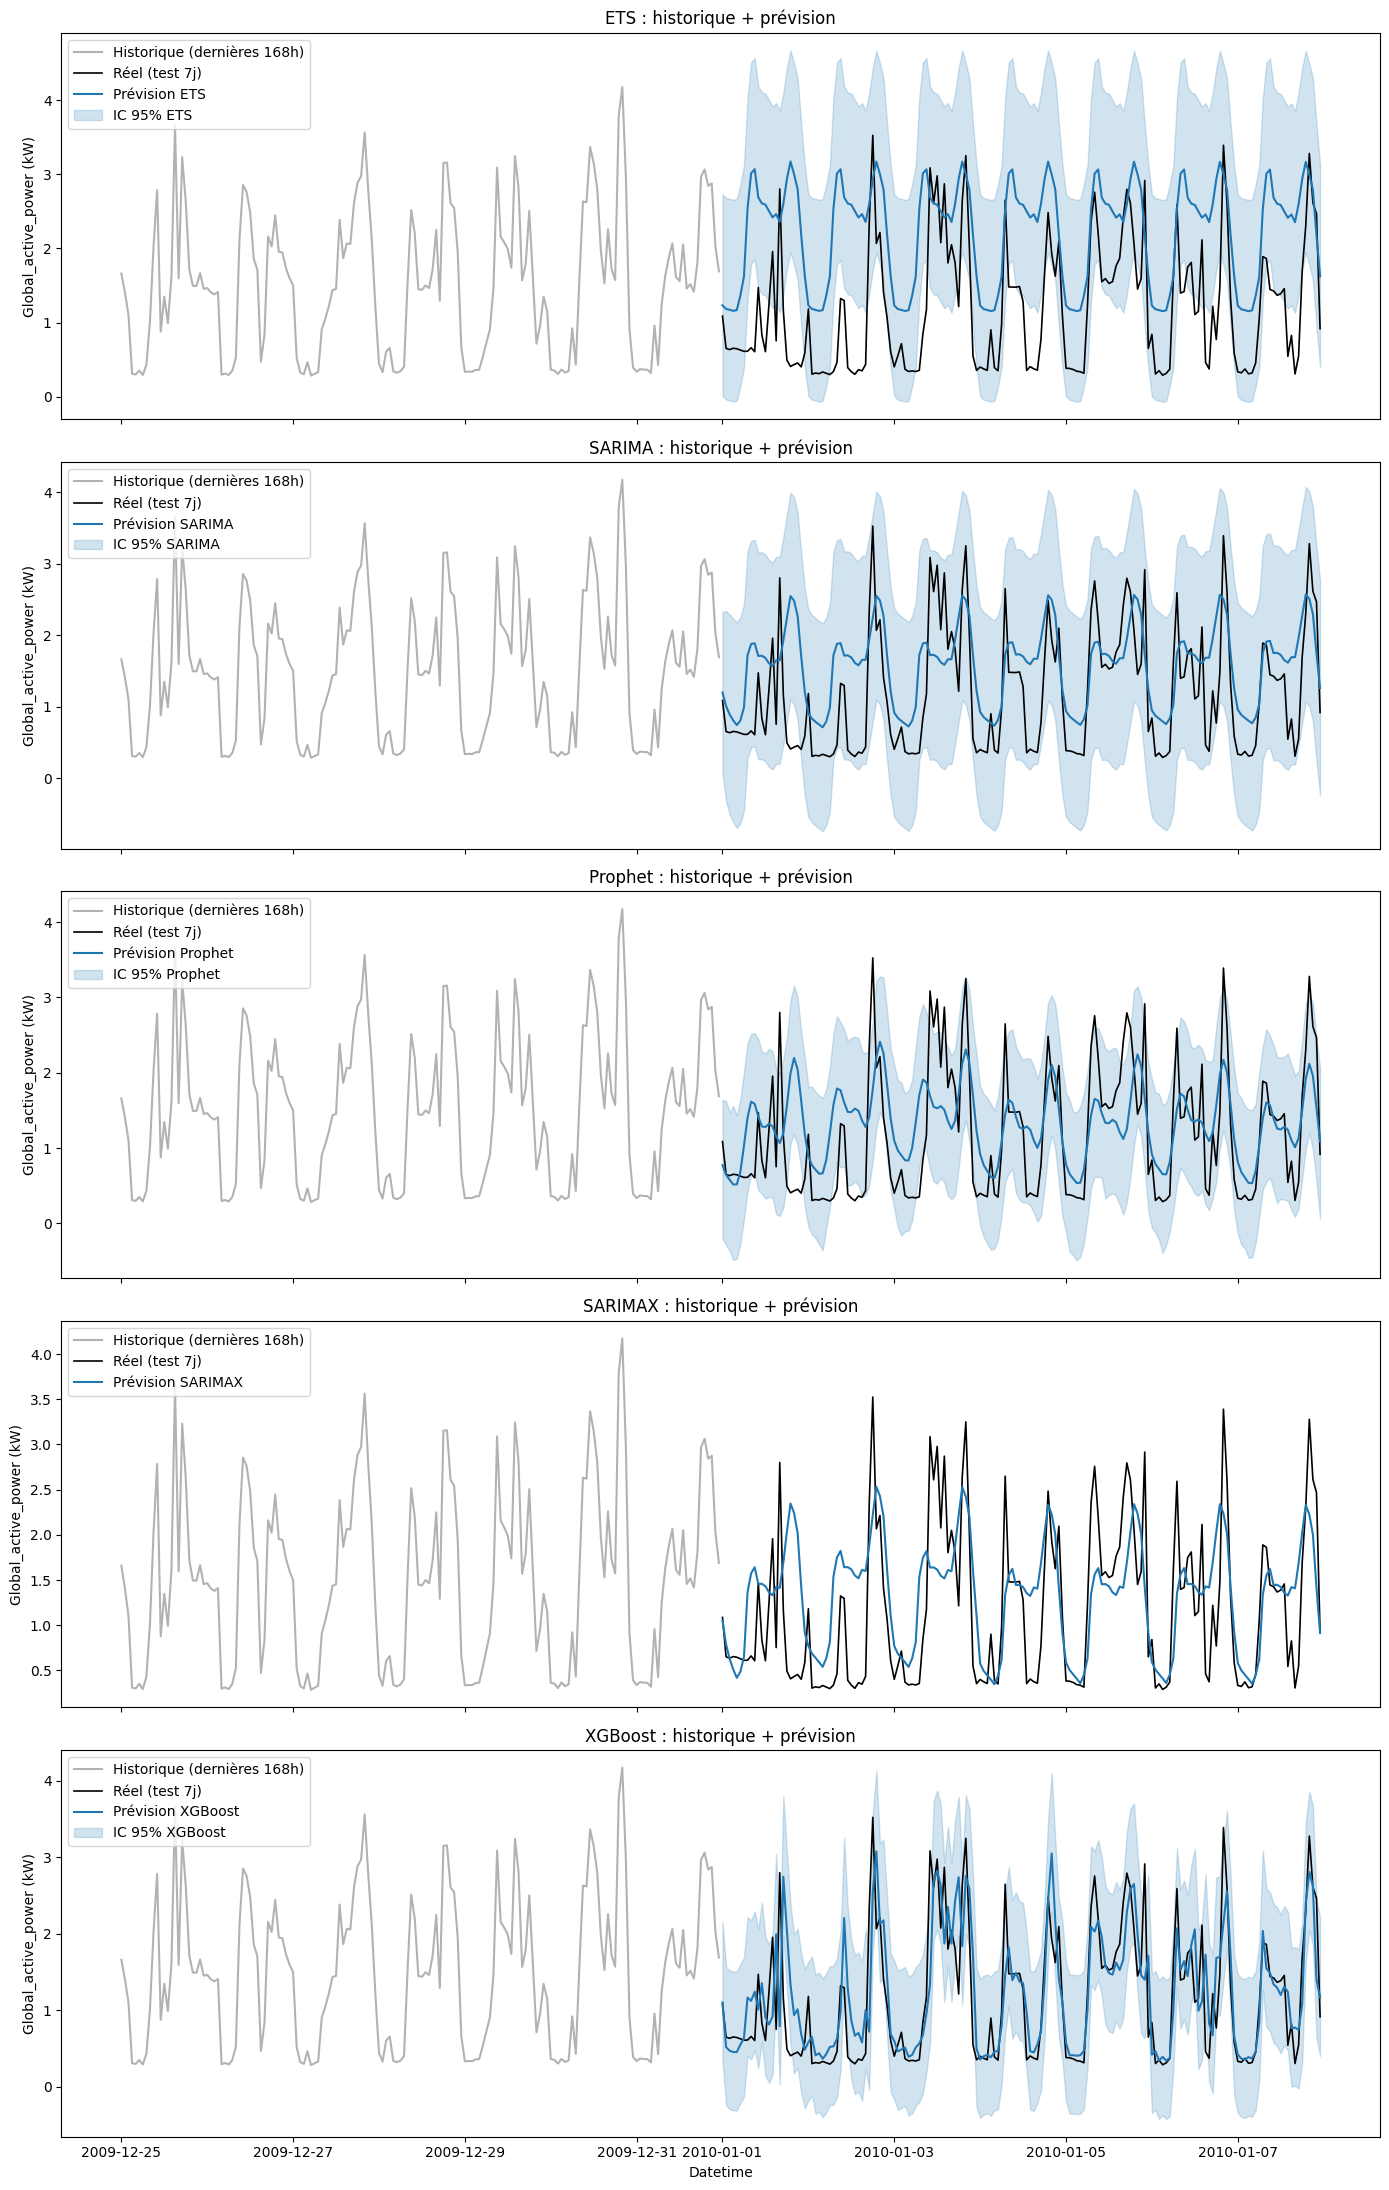

In [46]:
model_intervals = [
    ('ETS', ets_forecast, ets_ci['ets_lower'], ets_ci['ets_upper']),
    ('SARIMA', sarima_forecast, sarima_ci['sarima_lower'], sarima_ci['sarima_upper']),
    ('Prophet', prophet_forecast, prophet_ci['prophet_lower'], prophet_ci['prophet_upper']),
    ('SARIMAX', sarimax_forecast, sarimax_ci['sarimax_lower'], sarimax_ci['sarimax_upper']),
    ('XGBoost', xgb_point, xgb_ci['xgb_lower'], xgb_ci['xgb_upper']),
]

fig, axes = plt.subplots(len(model_intervals), 1, figsize=(14, 22), sharex=True)

if len(model_intervals) == 1:
    axes = [axes]

for ax, (name, forecast, lower, upper) in zip(axes, model_intervals):
    ax.plot(train.index[-168:], train[-168:], color='gray', alpha=0.6, label='Historique (dernières 168h)')
    ax.plot(test_7d.index, test_7d, color='black', linewidth=1.2, label='Réel (test 7j)')
    ax.plot(forecast.index, forecast, color='tab:blue', linewidth=1.5, label=f'Prévision {name}')
    if lower.notna().any() and upper.notna().any():
        ax.fill_between(forecast.index, lower, upper, color='tab:blue', alpha=0.2, label=f'IC 95% {name}')
    ax.set_title(f'{name} : historique + prévision')
    ax.set_ylabel('Global_active_power (kW)')
    ax.legend(loc='upper left')

axes[-1].set_xlabel('Datetime')
plt.tight_layout()
plt.show()

In [41]:
# --- Model Comparison Table ---
comparison = pd.DataFrame({
    'ETS': ets_metrics,
    'SARIMA': sarima_metrics,
    'Prophet': prophet_metrics,
    'SARIMAX': sarimax_metrics,
    'XGBoost': xgb_metrics
}).T
print('\n=== Model Comparison ===')
print(comparison.to_string())


=== Model Comparison ===
             RMSE       MAE       MAPE
ETS      1.267142  1.090644        NaN
SARIMA   0.782512  0.647402        NaN
Prophet  0.708763  0.569960  86.037854
SARIMAX  0.710066  0.543285  78.439159
XGBoost  0.570497  0.392113  44.119146


----> XgBoost is the winner !!

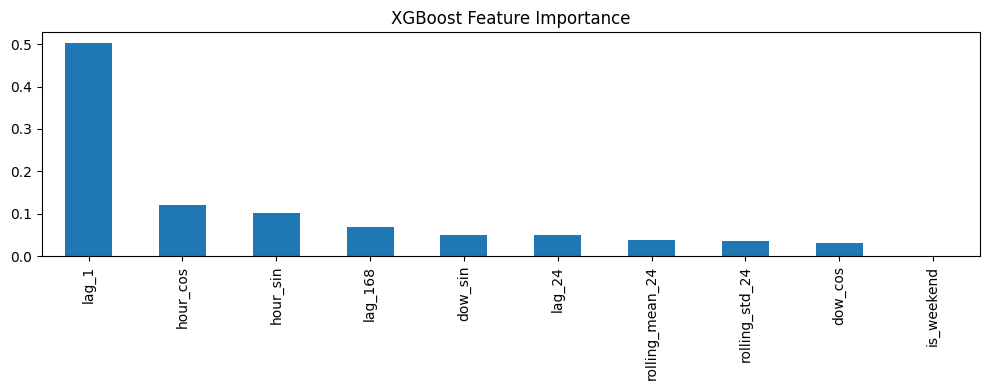

In [28]:
# --- Feature Importance ---
feat_imp = pd.Series(xgb_model.feature_importances_, index=train_features.columns).sort_values(ascending=False)
feat_imp.plot(kind='bar', figsize=(10, 4), title='XGBoost Feature Importance')
plt.tight_layout()
plt.show()

#### Conclusion
Ce graphique montre que XGBoost a principalement appris trois choses :
- 1) La consommation dépend fortement du passé immédiat
    lag_1 domine avec environ 50 % d'importance.
    ➡️ La consommation électrique possède une forte continuité temporelle.
- 2) Le cycle quotidien est essentiel
    hour_sin + hour_cos représentent environ 22 %.
    ➡️ Les habitudes horaires des occupants sont très importantes.
- 3) Les cycles plus longs existent mais sont secondaires
    lag_168, lag_24, dow_sin, dow_cos
    ➡️ Le modèle exploite les répétitions journalières et hebdomadaires.

En résumé :
XGBoost a réussi à transformer l'historique de consommation et les informations calendaires en règles prédictives. Il a découvert que la meilleure information pour prédire la consommation actuelle est d'abord la consommation juste avant, puis l'heure de la journée, puis les cycles journaliers et hebdomadaires.

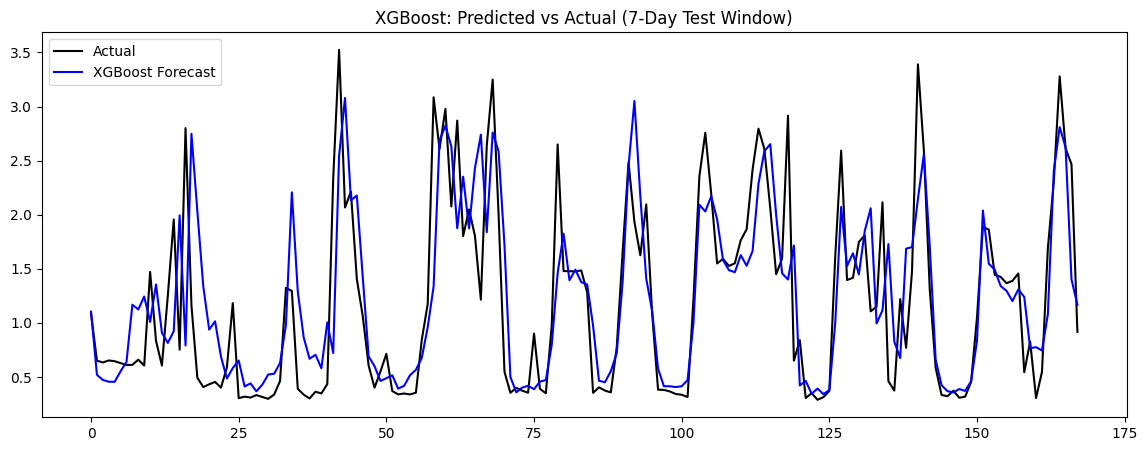

In [29]:
# --- Predicted vs Actual ---
plt.figure(figsize=(14, 5))
plt.plot(y_test_7d.values, label='Actual', color='black')
plt.plot(xgb_predictions, label='XGBoost Forecast', color='blue')
plt.title('XGBoost: Predicted vs Actual (7-Day Test Window)')
plt.legend()
plt.show()

### What if your models are leaving accuracy on the table by ignoring weather?

Residential power demand correlates with outdoor temperature. Heating and cooling loads spike when conditions deviate from comfortable ranges. In this mission, you add temperature as an external regressor to both SARIMAX and Prophet, quantify whether it improves accuracy, then close the loop by converting your best model's forecast into a real genset sizing recommendation using ISO 8528-1 and IEC 60364 methodology.

In [30]:
# Simulate synthetic temperature data (replace with real data if available)
# Using a sinusoidal proxy: avg 12C, amplitude 8C, daily cycle
np.random.seed(42)
all_index = pd.date_range(start='2007-01-01', end='2010-01-07 23:00', freq='H')
temp_series = pd.Series(
    12 + 8 * np.sin(2 * np.pi * (all_index.dayofyear / 365)) +
    3 * np.sin(2 * np.pi * (all_index.hour / 24)) +
    np.random.normal(0, 1, len(all_index)),
    index=all_index,
    name='temperature'
)

train_temp = temp_series.loc[train.index]
test_7d_temp = temp_series.loc[test_7d.index]

In [31]:
# --- SARIMAX with Temperature ---
train_exog_temp = train_exog.copy()
train_exog_temp['temperature'] = train_temp.values

test_7d_exog_temp = test_7d_exog.copy()
test_7d_exog_temp['temperature'] = test_7d_temp.values

sarimax_temp_model = SARIMAX(
    train,
    exog=train_exog_temp,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, low_memory=True) ### low_memory=True (MemoryError: Unable to allocate 136. MiB for an array with shape (26, 26, 26305) and data type float64)

sarimax_temp_forecast = sarimax_temp_model.forecast(168, exog=test_7d_exog_temp)
sarimax_temp_rmse = np.sqrt(mean_squared_error(test_7d, sarimax_temp_forecast))
sarimax_temp_mae = mean_absolute_error(test_7d, sarimax_temp_forecast)
sarimax_temp_mape = np.mean(np.abs((test_7d.values - sarimax_temp_forecast.values) / test_7d.values)) * 100
sarimax_temp_metrics = {'RMSE': sarimax_temp_rmse, 'MAE': sarimax_temp_mae, 'MAPE': sarimax_temp_mape}
print(f'SARIMAX+Temp RMSE: {sarimax_temp_rmse:.4f} | MAE: {sarimax_temp_mae:.4f} | MAPE: {sarimax_temp_mape:.2f}%')

SARIMAX+Temp RMSE: 0.7125 | MAE: 0.5459 | MAPE: 79.27%


## Prophet with temperature variable

In [35]:
# --- Prophet with Temperature ---
train_prophet_temp = train_prophet.copy()
train_prophet_temp['temperature'] = train_temp.values

prophet_temp_model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False, uncertainty_samples=0)
prophet_temp_model.add_regressor('temperature')
prophet_temp_model.fit(train_prophet_temp)

future_temp = prophet_temp_model.make_future_dataframe(periods=168, freq='H')
future_temp['temperature'] = temp_series.loc[future_temp['ds']].values
prophet_temp_pred = prophet_temp_model.predict(future_temp)
prophet_temp_forecast = prophet_temp_pred.set_index('ds')['yhat'].loc[test_7d.index]
prophet_temp_rmse = np.sqrt(mean_squared_error(test_7d, prophet_temp_forecast))
prophet_temp_mae = mean_absolute_error(test_7d, prophet_temp_forecast)
prophet_temp_mape = np.mean(np.abs((test_7d.values - prophet_temp_forecast.values) / test_7d.values)) * 100
prophet_temp_metrics = {'RMSE': prophet_temp_rmse, 'MAE': prophet_temp_mae, 'MAPE': prophet_temp_mape}
print(f'Prophet+Temp RMSE: {prophet_temp_rmse:.4f} | MAE: {prophet_temp_mae:.4f} | MAPE: {prophet_temp_mape:.2f}%')

09:46:05 - cmdstanpy - INFO - Chain [1] start processing
09:46:14 - cmdstanpy - INFO - Chain [1] done processing


Prophet+Temp RMSE: 0.7562 | MAE: 0.6259 | MAPE: 104.30%


In [36]:
# --- Weather Impact Comparison ---
weather_comparison = pd.DataFrame({
    'SARIMAX (calendar only)': sarimax_metrics,
    'SARIMAX + Temperature': sarimax_temp_metrics,
    'Prophet (calendar only)': prophet_metrics,
    'Prophet + Temperature': prophet_temp_metrics
}).T
print('\n=== Weather Regressor Impact ===')
print(weather_comparison.to_string())


=== Weather Regressor Impact ===
                             RMSE       MAE        MAPE
SARIMAX (calendar only)  0.710066  0.543285   78.439159
SARIMAX + Temperature    0.712536  0.545903   79.272193
Prophet (calendar only)  0.708763  0.569960   86.037854
Prophet + Temperature    0.756200  0.625882  104.300222


On remarque ici que l'ajout de la température a dégradé les performances des modèles (le RMSE, le MAE et le MAPE ont augmenté, particulièrement pour Prophet).

Voici pourquoi :

- La nature synthétique des données : La température utilisée ici est simulée par une courbe sinusoïdale lisse avec du bruit aléatoire. Elle ne reflète pas les vraies variations météorologiques locales de cette période, ce qui apporte du bruit inutile au modèle.

- Une relation non-linéaire : La consommation électrique liée à la météo ne varie pas de manière linéaire. Elle suit souvent une courbe en "U" (on consomme beaucoup s'il fait très froid pour le chauffage, et s'il fait très chaud pour la climatisation). Un régresseur linéaire direct peut donc induire le modèle SARIMAX ou Prophet en erreur s'il n'est pas transformé au préalable (par exemple, en créant des indicateurs de seuils de température).

- Le phénomène de surapprentissage (overfitting) : Ajouter un exogenous regressor qui n'a pas de lien direct et propre avec la cible force le modèle à chercher des corrélations inexistantes, ce qui détériore ses prévisions sur le jeu de test (le MAPE de Prophet grimpe ainsi de 86 % à 104 %).

### Saving training models

In [ ]:
import pickle

models = {
    'ets': ets_model,
    'sarima': sarima_model,
    'prophet': prophet_model,
    'sarimax': sarimax_model,
    'xgboost': xgb_model,
    'prophet_temp': prophet_temp_model,
    'sarimax_temp': sarimax_temp_model
}

with open('trained_models.pkl', 'wb') as f:
    pickle.dump(models, f)

print('Saved trained models to trained_models.pkl')

# =============================================
# GENSET SIZING (from best model: XGBoost)
# =============================================

In [37]:

POWER_FACTOR = 0.8
SAFETY_MARGIN = 1.25
STANDARD_SIZES = [5, 8, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 200]

predicted_peak_kw = float(np.max(best_forecast))
predicted_avg_kw = float(np.mean(best_forecast))

required_kva = predicted_peak_kw / POWER_FACTOR
sized_kva = required_kva * SAFETY_MARGIN

# Map to next standard genset size
recommended_genset = next((s for s in STANDARD_SIZES if s >= sized_kva), STANDARD_SIZES[-1])

# Compute load factor and check healthy range
load_factor = predicted_avg_kw / predicted_peak_kw
lf_status = 'HEALTHY' if 0.30 <= load_factor <= 0.80 else 'WARNING: outside 30-80% range'

- 1. **La conversion des kW en kVA**

Les modèles de Machine Learning prédisent la puissance active consommée par la maison en kW (kilowatts). Cependant, les groupes électrogènes sont vendus et classés selon leur puissance apparente en kVA (kilovoltampères).
La ``norme ISO 8528-1`` indique que pour les alternateurs triphasés, on applique un Power Factor (facteur de puissance) de 0,8 pour faire la conversion :

$kVA = kW / 0.8$

- 2. **La marge de sécurité de 25 %**

Pour éviter que le générateur ne fonctionne à 100 % de ses capacités (ce qui l'endommagerait) et pour absorber les hausses soudaines d'électricité (comme le démarrage d'un climatiseur ou d'un moteur), on ajoute une marge de sécurité de 25 % :

$kVA_final = kVA * 1.25$

- 3. **L'arrondi à la taille standard du marché**

Dans le commerce, vous ne pouvez pas acheter un générateur de 12,4 kVA ou de 21,7 kVA. Les fabricants proposent des tailles standards : 5, 8, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 200 kVA.
Vous devez donc arrondir au chiffre supérieur le plus proche dans cette liste. Par exemple, si votre calcul donne 12,4 kVA, vous choisirez un générateur de 15 kVA.

- 4. **La vérification du taux de charge (Load Factor)**
Une fois le générateur choisi, vous devez vérifier que le load factor (votre consommation moyenne divisée par la capacité maximale du générateur) se situe bien dans une zone saine, entre 30 % et 80 %.

    - **En dessous de 30 % :** Le moteur du générateur tourne "à vide" (pas assez chargé), ce qui entraîne une mauvaise combustion du carburant et encrasse le moteur (phénomène de wet stacking).

    - **Au-dessus de 80 % :** Le générateur est trop sollicité et risque de surchauffer ou de s'user prématurément.

In [38]:
print('\n=== GENERATOR SET SIZING REPORT ===')
print(f'Predicted peak:       {predicted_peak_kw:.2f} kW')
print(f'Predicted average:    {predicted_avg_kw:.2f} kW')
print(f'Required apparent:    {required_kva:.2f} kVA  (PF={POWER_FACTOR}, ISO 8528-1)')
print(f'With 25% margin:      {sized_kva:.2f} kVA')
print(f'Recommended genset:   {recommended_genset} kVA  (next standard size)')
print(f'Load factor:          {load_factor:.2%}  [{lf_status}]')
print(f'\nJustification: Peak demand of {predicted_peak_kw:.2f} kW converted to {required_kva:.2f} kVA')
print(f'at PF=0.8 per ISO 8528-1. 25% safety margin per IEC 60364 yields {sized_kva:.2f} kVA.')
print(f'Nearest standard size: {recommended_genset} kVA.')


=== GENERATOR SET SIZING REPORT ===
Predicted peak:       3.08 kW
Predicted average:    1.23 kW
Required apparent:    3.85 kVA  (PF=0.8, ISO 8528-1)
With 25% margin:      4.81 kVA
Recommended genset:   5 kVA  (next standard size)
Load factor:          39.96%  [HEALTHY]

Justification: Peak demand of 3.08 kW converted to 3.85 kVA
at PF=0.8 per ISO 8528-1. 25% safety margin per IEC 60364 yields 4.81 kVA.
Nearest standard size: 5 kVA.
